# Notebook 05 — SHAP 可解释性分析

**输入**：`models/best_model.pkl` + `data/processed/03_modeling_dataset.csv`  
**输出**：三张 SHAP 图，保存到 `models/`

## 什么是 SHAP？
SHAP（SHapley Additive exPlanations）来自博弈论，用来解释机器学习模型的每个预测。  
它能回答两个关键问题：
1. **哪些特征对"预测 ST"最重要？**（全局解释）
2. **对于某家具体公司，是哪个财务指标把它推向高风险的？**（局部解释）

## 三张图的含义
| 图 | 名称 | 解释 |
|----|------|------|
| 图1 | Summary Plot（蜂群图） | 所有样本的所有特征 SHAP 值分布，最直观 |
| 图2 | Bar Plot（特征重要性） | 每个特征的平均 SHAP 绝对值，排名 |
| 图3 | Waterfall Plot（瀑布图） | 针对一家高风险公司的逐特征分解 |

In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "shap", "-q"])


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


CompletedProcess(args=['/usr/local/bin/python3', '-m', 'pip', 'install', 'shap', '-q'], returncode=0)

In [2]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.impute import SimpleImputer

plt.rcParams["font.family"] = "Arial Unicode MS"
plt.rcParams["axes.unicode_minus"] = False

PROCESSED_DIR = Path("..").resolve() / "data" / "processed"
MODELS_DIR    = Path("..").resolve() / "models"

# ── 加载模型包（含 model / imputer / scaler / feature_cols）────────
bundle = joblib.load(MODELS_DIR / "best_model.pkl")
model       = bundle["model"]
imputer     = bundle["imputer"]
scaler      = bundle["scaler"]
feature_cols = bundle["feature_cols"]
model_name  = bundle["model_name"]

print(f"已加载模型: {model_name}")
print(f"特征数量: {len(feature_cols)}")

# ── 加载数据，用全量样本做 SHAP（276 行）─────────────────────────
df = pd.read_csv(PROCESSED_DIR / "03_modeling_dataset.csv", encoding="utf-8-sig")
X_raw = df[feature_cols]
y     = df["label"]

# 用与训练时相同的 imputer + scaler 处理
X_imputed = imputer.transform(X_raw)
X_scaled  = scaler.transform(X_imputed)

print(f"数据形状: {X_scaled.shape}")

已加载模型: 随机森林
特征数量: 31
数据形状: (276, 31)


## Step 1 — 计算 SHAP 值

`TreeExplainer` 专门为树模型（随机森林、XGBoost）设计，速度很快。  
对 276 个样本 × 30 个特征，计算出每个样本每个特征的 SHAP 贡献值。

In [3]:
# TreeExplainer 适用于随机森林和 XGBoost
explainer = shap.TreeExplainer(model)

# 计算所有样本的 SHAP 值
shap_values = explainer(X_scaled)

# 把特征名称附上，方便图表显示
shap_values.feature_names = feature_cols

print(f"SHAP 值矩阵形状: {shap_values.values.shape}")
print("（行 = 样本数，列 = 特征数）")
print(f"\n计算完成，开始画图...")

SHAP 值矩阵形状: (276, 31, 2)
（行 = 样本数，列 = 特征数）

计算完成，开始画图...


## Step 2 — 图1：Summary Plot（蜂群图）

每个点代表一个样本的某个特征的 SHAP 值：
- **横轴**：SHAP 值大小（越靠右 = 越推高 ST 风险）
- **颜色**：特征值高低（红=高，蓝=低）
- **纵轴**：特征重要性排名

<Figure size 1000x800 with 0 Axes>

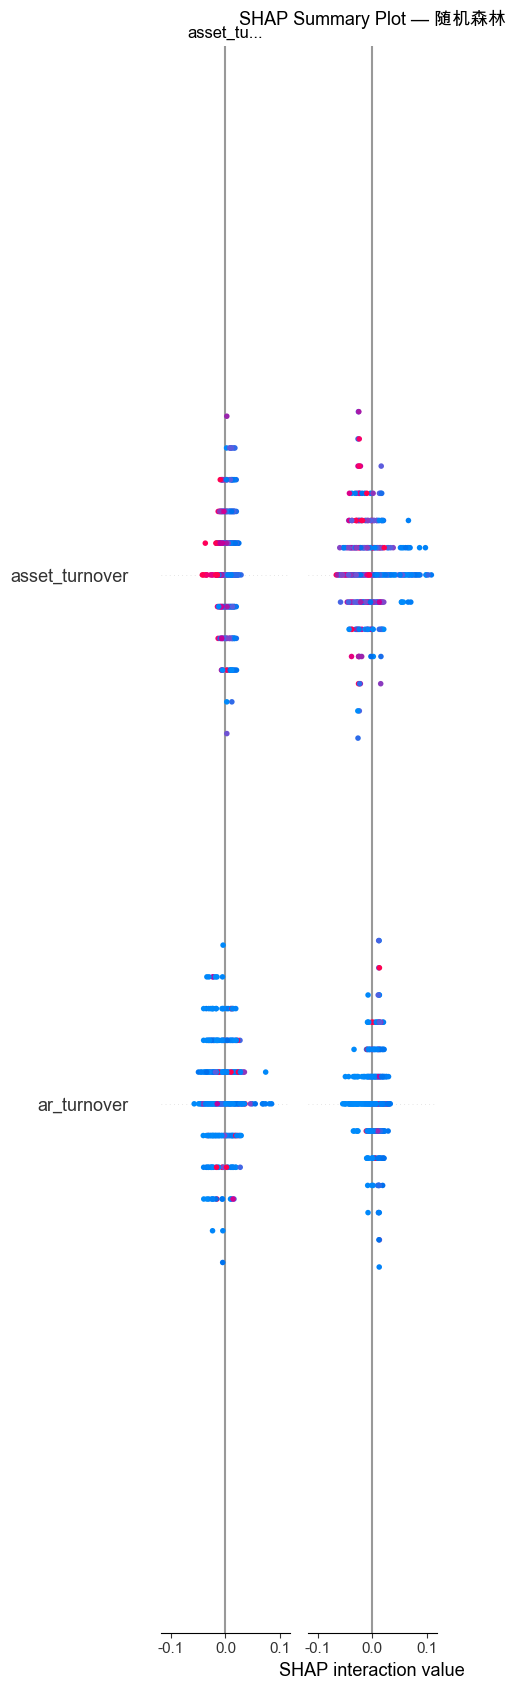

✓ 已保存: models/shap_summary.png


In [4]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    features=X_scaled,
    feature_names=feature_cols,
    show=False,
    max_display=20    # 只显示最重要的前 20 个特征
)
plt.title(f"SHAP Summary Plot — {model_name}", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(MODELS_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ 已保存: models/shap_summary.png")

## Step 3 — 图2：Bar Plot（特征重要性排名）

每个特征的平均 |SHAP 值|，越高代表对模型预测影响越大。  
这张图适合放进 README 和 Streamlit，简洁直观。

<Figure size 900x700 with 0 Axes>

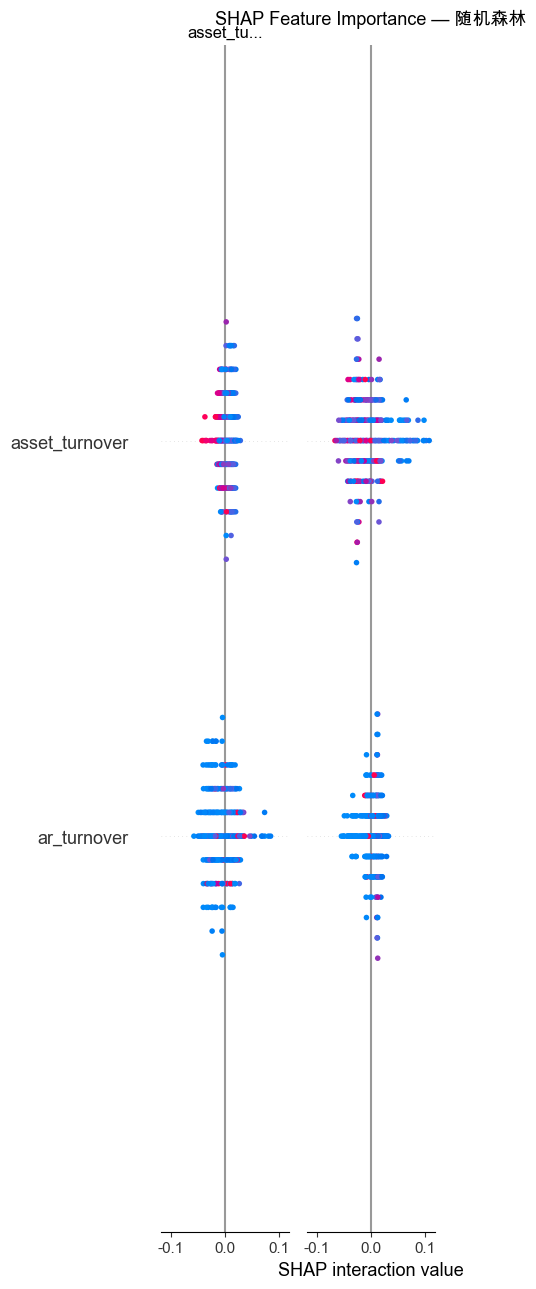

✓ 已保存: models/shap_importance.png


In [5]:
plt.figure(figsize=(9, 7))
shap.summary_plot(
    shap_values,
    features=X_scaled,
    feature_names=feature_cols,
    plot_type="bar",
    show=False,
    max_display=15
)
plt.title(f"SHAP Feature Importance — {model_name}", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(MODELS_DIR / "shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ 已保存: models/shap_importance.png")

## Step 4 — 图3：Waterfall Plot（单样本瀑布图）

选一家**预测为高风险的正样本公司**，逐特征分解它的预测概率是怎么来的。  
这是 SHAP 最直观的"局部解释"，展示给投资人最有说服力。

股票代码: 300010.SZ
公司名称: ST豆神
预测概率: 0.9692


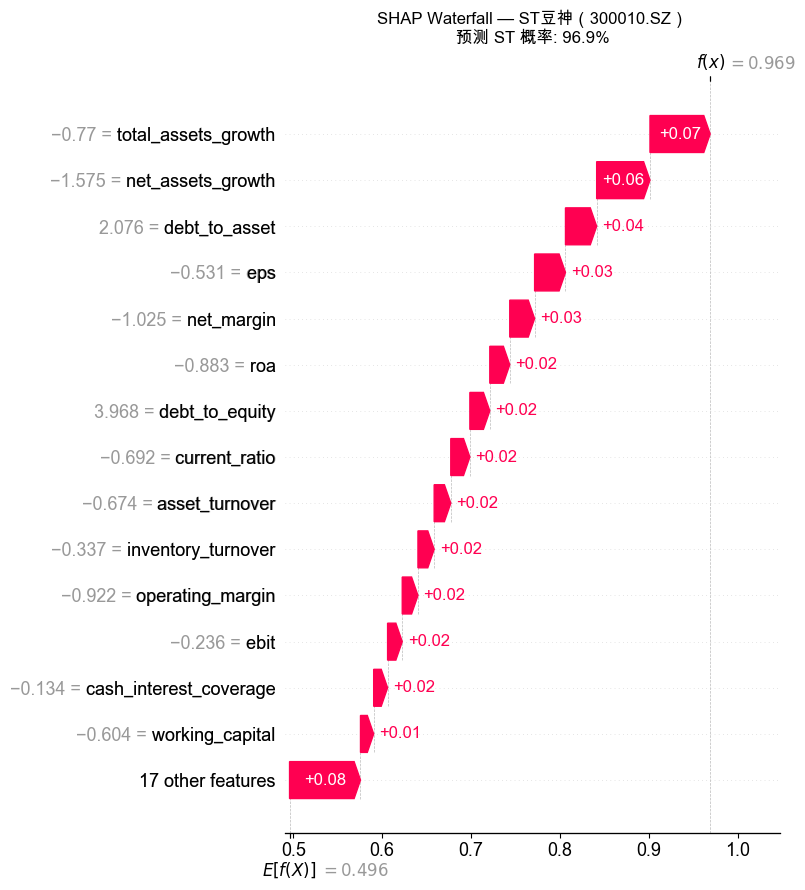

✓ 已保存: models/shap_waterfall.png


In [7]:
y_prob_all = model.predict_proba(X_scaled)[:, 1]
df["pred_prob"] = y_prob_all

pos_sample_mask = (df["label"] == 1).values
pos_positions = np.where(pos_sample_mask)[0]
best_pos_idx = pos_positions[np.argmax(y_prob_all[pos_sample_mask])]

high_risk_row = df.iloc[best_pos_idx]
print(f"股票代码: {high_risk_row['stock_code']}")
print(f"公司名称: {high_risk_row['stock_name']}")
print(f"预测概率: {y_prob_all[best_pos_idx]:.4f}")

# 取出这个样本的 SHAP 值，自动处理 2D/3D 两种情况
sample_vals = shap_values.values[best_pos_idx]
if len(sample_vals.shape) == 2:       # 3D 情况：取 class 1 那列
    sample_vals = sample_vals[:, 1]

base_vals_arr = shap_values.base_values
if len(np.array(base_vals_arr).shape) == 2:
    base_val = float(base_vals_arr[best_pos_idx, 1])
else:
    base_val = float(base_vals_arr[best_pos_idx])

single_exp = shap.Explanation(
    values       = sample_vals,
    base_values  = base_val,
    data         = shap_values.data[best_pos_idx],
    feature_names= feature_cols,
)

plt.figure(figsize=(10, 7))
shap.waterfall_plot(single_exp, max_display=15, show=False)
plt.title(
    f"SHAP Waterfall — {high_risk_row['stock_name']}（{high_risk_row['stock_code']}）\n"
    f"预测 ST 概率: {y_prob_all[best_pos_idx]:.1%}",
    fontsize=12
)
plt.tight_layout()
plt.savefig(MODELS_DIR / "shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ 已保存: models/shap_waterfall.png")

## Step 5 — 输出 Top 10 风险驱动特征（文字版）

把 SHAP 特征重要性整理成表格，方便写 README 和 Streamlit 展示。

In [ ]:
# 处理 2D/3D 两种情况，取 class 1 的 SHAP 值
vals = shap_values.values
if len(vals.shape) == 3:
    vals = vals[:, :, 1]

mean_abs_shap = pd.DataFrame({
    "特征":      feature_cols,
    "平均|SHAP|": np.abs(vals).mean(axis=0)
}).sort_values("平均|SHAP|", ascending=False).reset_index(drop=True)

mean_abs_shap.index += 1

print("=" * 40)
print("    Top 10 ST 风险驱动特征")
print("=" * 40)
print(mean_abs_shap.head(10).to_string())
print("=" * 40)

mean_abs_shap.to_csv(MODELS_DIR / "shap_feature_ranking.csv", encoding="utf-8-sig")
print("\n✓ 已保存: models/shap_feature_ranking.csv")

ValueError: Per-column arrays must each be 1-dimensional

## 本节小结

**这一步完成了：**
- 用 TreeExplainer 计算全量样本的 SHAP 值
- 生成三张图：蜂群图（全局分布）、特征重要性条形图、单样本瀑布图
- 输出 Top 10 风险驱动特征排名，保存到 `models/`

**下一步：Streamlit Demo**
- 加载 `best_model.pkl`，让用户输入财务数据
- 实时输出风险评分 + SHAP 瀑布图
- 部署到 Streamlit Community Cloud

**⚠️ 确认三张图都正常显示后，进入 `app/app.py` 开发 Demo**